In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from nltk.tokenize import TweetTokenizer
from nltk.tokenize import TweetTokenizer
from nltk.stem.wordnet import WordNetLemmatizer
import seaborn as sns


In [4]:
df = pd.read_csv("cyberbullying_tweets.csv")


In [7]:
#Preprocessing data
df.dropna(inplace=True)
df['tweet_text'] = df['tweet_text'].str.replace(r'\s*@\w+\s*', '', regex=True)                  #Removing @ mentions
df['tweet_text'] = df['tweet_text'].str.replace(r'https?://\S+|http?://\S+', '', regex=True)    #Removing URLs
df['tweet_text'] = df['tweet_text'].str.lower()                                                 #Lowercasing all words
tweet_tokenizer = TweetTokenizer()
df['tokenized_tweet'] = df['tweet_text'].apply(lambda x: tweet_tokenizer.tokenize(x))           #tokenized tweets //Time Consuming
lemmatizer = WordNetLemmatizer()                                                                #Lemmatize eg. doing = do,going=go 
df['tokenized_tweet'] = df['tokenized_tweet'].apply(lambda x: [lemmatizer.lemmatize(word, pos='v') for word in x]) 

In [10]:
#df

C:\Users\adiks\AppData\Local\Temp\ipykernel_23248\3848463504.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='text_len', data=df[df['text_len']<10], palette='mako')


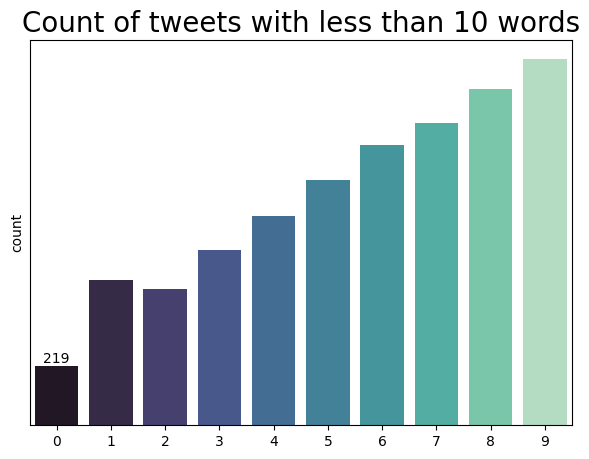

In [11]:
df['text_len'] = [len(text.split()) for text in df.tweet_text]
plt.figure(figsize=(7,5))
ax = sns.countplot(x='text_len', data=df[df['text_len']<10], palette='mako')
plt.title('Count of tweets with less than 10 words', fontsize=20)
plt.yticks([])
ax.bar_label(ax.containers[0])
plt.ylabel('count')
plt.xlabel('')
plt.show()

In [14]:
df.sort_values(by=['text_len'], ascending=True)
df = df[df['tweet_text'].notna()]
df


,tweet_text,cyberbullying_type,tokenized_tweet,text_len
0,"in other words #katandandre, your food was cra...",not_cyberbullying,"[in, other, word, #katandandre, ,, your, food,...",9
1,why is #aussietv so white? #mkr #theblock #ima...,not_cyberbullying,"[why, be, #aussietv, so, white, ?, #mkr, #theb...",14
2,a classy whore? or more red velvet cupcakes?,not_cyberbullying,"[a, classy, whore, ?, or, more, red, velvet, c...",8
3,"meh. :p thanks for the heads up, but not too ...",not_cyberbullying,"[meh, ., :p, thank, for, the, head, up, ,, but...",17
4,this is an isis account pretending to be a kur...,not_cyberbullying,"[this, be, an, isis, account, pretend, to, be,...",17
...,...,...,...,...
47687,"black ppl aren't expected to do anything, depe...",ethnicity,"[black, ppl, aren't, expect, to, do, anything,...",42
47688,turner did not withhold his disappointment. tu...,ethnicity,"[turner, do, not, withhold, his, disappointmen...",45
47689,i swear to god. this dumb nigger bitch. i have...,ethnicity,"[i, swear, to, god, ., this, dumb, nigger, bit...",20
47690,yea fuck you rt: if youre a nigger fucking unf...,ethnicity,"[yea, fuck, you, rt, :, if, youre, a, nigger, ...",14
